# **Unsupervised Learning Project: AllLife Bank Customer Segmentation**

# **Marks: 30**

Welcome to the project on Unsupervised Learning. We will be using **Credit Card Customer Data** for this project.

--------------------------------
## **Context**
-------------------------------

**AllLife Bank wants to focus on its credit card customer base** in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers.

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.


----------------------------
## **Objective**
-----------------------------

**Identify different segments in the existing customer base**, taking into account their spending patterns as well as past interactions with the bank.

--------------------------
## **About the data**
--------------------------

Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.

- **Sl_no** - Customer Serial Number
- **Customer Key** - Customer identification
- **Avg_Credit_Limit**	- Average credit limit (currency is not specified, you can make an assumption around this)
- **Total_Credit_Cards** - Total number of credit cards
- **Total_visits_bank**	- Total bank visits
- **Total_visits_online** - Total online visits
- **Total_calls_made** - Total calls made

## **Importing libraries and overview of the dataset**

**Note:** Please make sure you have installed the sklearn_extra library before running the below cell. If you have not installed the library, please run the below code to install the library:

In [ ]:
!pip install scikit-learn-extra

**Note**: After running this commands, you’ll be prompted to restart your notebook/runtime. Please go ahead and do that. Once restarted, simply proceed to the next step of your workflow

In [ ]:
!pip install numpy==1.26.0

### **Loading the data**

In [ ]:
#Libraries that read and manipulate data
import pandas as pd
import numpy as np
#Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Supress warnings
import warnings
warnings.filterwarnings('ignore')

#To scale data using z-score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# To perform K-means clustering abd silhouette scores
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
# To perform hierarchical clustering, compute cophentic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Credit Card Customer Data.xlsx")

### **Data Overview**

- Observations
- Sanity checks




In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


Observations: The data set is comprised of 7 columns labeled S1_No, Customer Key, Avg_Credit_Limit, Total_credit_cards, Total_visits_bank, and Total_visits_online. The first two columns are unique customer identification keys, and will not add any information to our data and can probably be dropped.

In [ ]:
df.shape

(660, 7)

Observations: The dataframe has 660 rows and 7 columns.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


Observations: The dataframe appears to have 0 null values. All of the columns consist of numerical data.

In [ ]:
# Copying the dataframe to another variable to avoid changes to original data.
df = df.copy()


In [ ]:
# Check for duplicated values
df.duplicated().sum()

0

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Credit Card Customer Data.xlsx")
df = df.drop(['Sl_No', 'Customer Key'], axis=1)
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [ ]:
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


There are no null values in the data.

## **Data Preprocessing and Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.
- Check and drop the duplicate customer keys
- Drop the variables that are not required for the analysis
- Check duplicate rows and remove them.


**Questions:**

1. How does the distribution and outliers look for each variable in the data?
2. How are the variables correlated with each other?

#### **Check the summary Statistics**

In [ ]:
df.describe(include='all')


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


Observations: The average credit limit is around 34,547. The minimum threshold is 3000 and the maximum threshold is 200,000. The average amount of credit cards held by each customer is 4-5, whereas the fewest held is 1 and the most held is 10. The average number of visits in person to a bank and online is roughly 2 per customer, the minimum is 0 visits and the maximum is 5 in person and 15 online. The average number of calls per customer is about 4, while the minimum number is 0 and the most calls is 10.

# Univariate Analysis


In [ ]:
#Function to create a histogram boxplot:
def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):

    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,  # Number of rows of the subplot grid= 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram


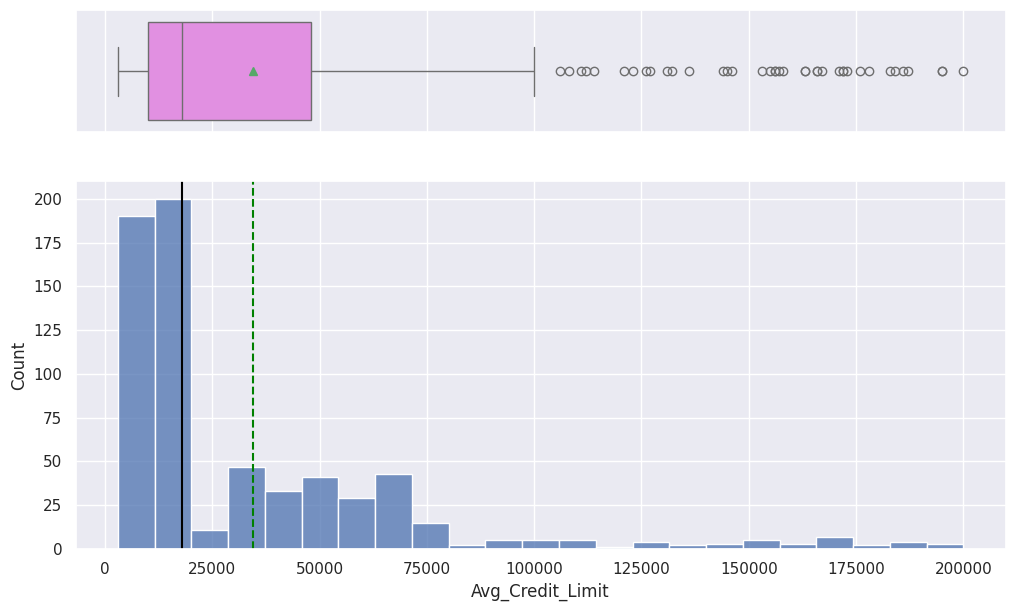

In [ ]:
histogram_boxplot(df, 'Avg_Credit_Limit')


Observations: There are many outliers represented in the box plot, which is confirmed by the severe right skew of the graph. These outliers will need to be handled. The outliers cannot be discarded in this case, however, because they represent high value customers to the bank.

In [ ]:
# Calculate Q1
Q1= df.quantile(0.25)
# Calculate Q3
Q3= df.quantile(0.75)
IQR = Q3 - Q1

#Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile):\n{Q1}")
print(f"Q3 (75th percentile):\n{Q3}")
print(f"IQR (Interquartile Range):\n{IQR}")
print(f"Lower bound:\n{lower_bound}")
print(f"Upper bound:\n{upper_bound}")

# Identify outliers
outliers = df[(df['Avg_Credit_Limit'] < lower_bound['Avg_Credit_Limit']) | (df['Avg_Credit_Limit'] > upper_bound['Avg_Credit_Limit'])]
print(f'\nNumbers of outliers detected: {len(outliers)}')
print('Outliers:')
display(outliers)

Q1 (25th percentile):
Avg_Credit_Limit       10000.0
Total_Credit_Cards         3.0
Total_visits_bank          1.0
Total_visits_online        1.0
Total_calls_made           1.0
Name: 0.25, dtype: float64
Q3 (75th percentile):
Avg_Credit_Limit       48000.0
Total_Credit_Cards         6.0
Total_visits_bank          4.0
Total_visits_online        4.0
Total_calls_made           5.0
Name: 0.75, dtype: float64
IQR (Interquartile Range):
Avg_Credit_Limit       38000.0
Total_Credit_Cards         3.0
Total_visits_bank          3.0
Total_visits_online        3.0
Total_calls_made           4.0
dtype: float64
Lower bound:
Avg_Credit_Limit      -47000.0
Total_Credit_Cards        -1.5
Total_visits_bank         -3.5
Total_visits_online       -3.5
Total_calls_made          -5.0
dtype: float64
Upper bound:
Avg_Credit_Limit       105000.0
Total_Credit_Cards         10.5
Total_visits_bank           8.5
Total_visits_online         8.5
Total_calls_made           11.0
dtype: float64

Numbers of outliers det

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
612,157000,9,1,14,1
614,163000,8,1,7,1
615,131000,9,1,10,1
617,136000,8,0,13,0
618,121000,7,0,13,2
619,158000,7,0,13,0
620,108000,10,0,15,1
621,166000,9,1,12,2
622,176000,10,1,15,2
623,166000,10,0,7,0


There are 39 outlier values in the "Avg_Credit_Limit" column. We will deal with these outliers by  capping them.

In [ ]:
# Cap the outliers
df['Avg_Credit_Limit_Capped'] = np.where(df['Avg_Credit_Limit'] > upper_bound['Avg_Credit_Limit'], upper_bound['Avg_Credit_Limit'], np.where(df['Avg_Credit_Limit'] < lower_bound['Avg_Credit_Limit'], lower_bound['Avg_Credit_Limit'], df['Avg_Credit_Limit']))
display(df.tail(10))

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Avg_Credit_Limit_Capped
650,195000,10,1,12,2,105000.0
651,132000,9,1,12,2,105000.0
652,156000,8,1,8,0,105000.0
653,95000,10,0,15,1,95000.0
654,172000,10,1,9,1,105000.0
655,99000,10,1,10,0,99000.0
656,84000,10,1,13,2,84000.0
657,145000,8,1,9,1,105000.0
658,172000,10,1,15,0,105000.0
659,167000,9,0,12,2,105000.0


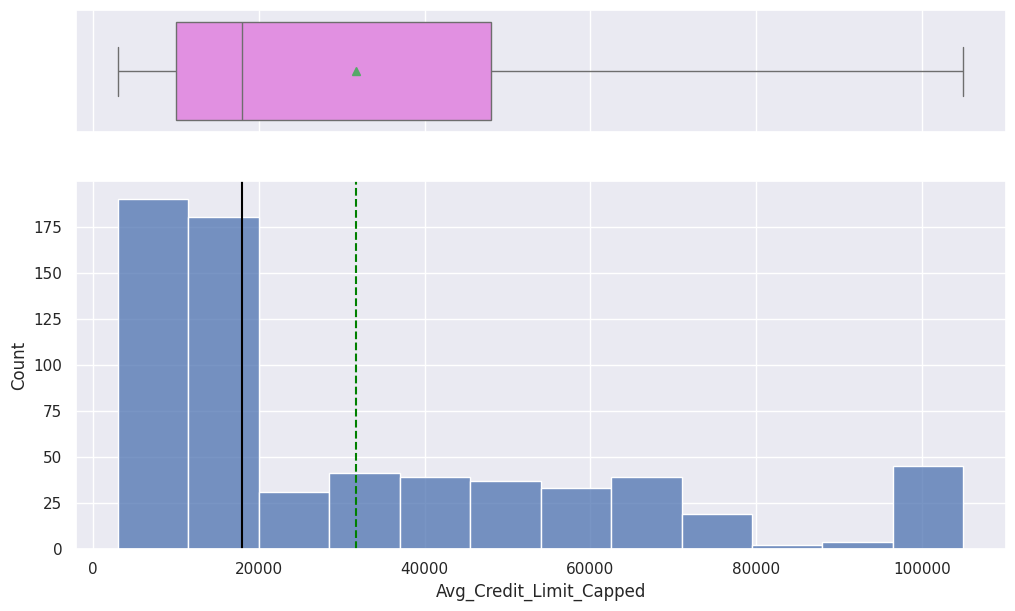

In [ ]:
# Check the capped values
histogram_boxplot(df, 'Avg_Credit_Limit_Capped')


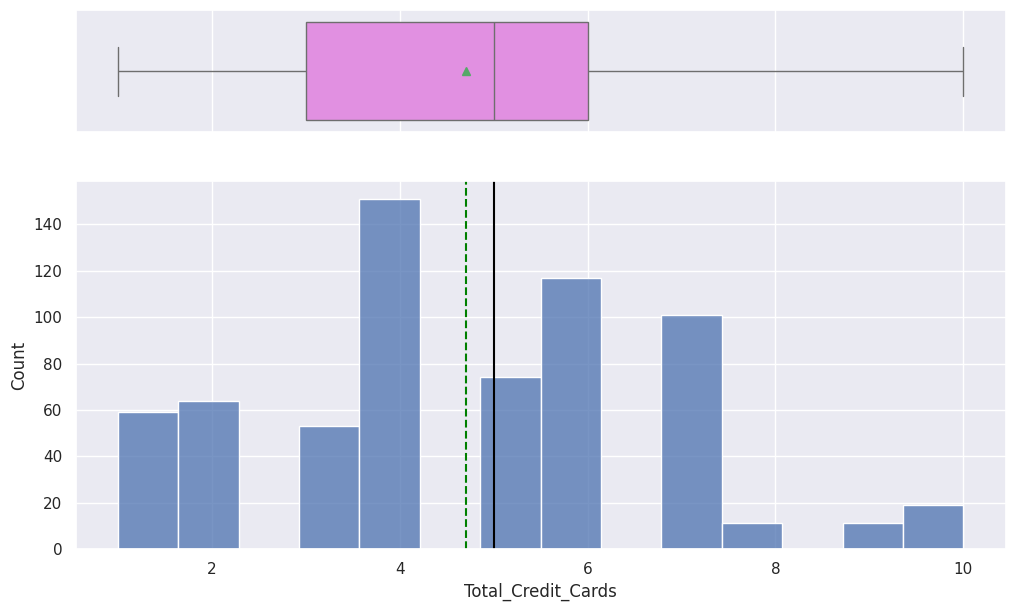

In [ ]:
histogram_boxplot(df, 'Total_Credit_Cards')

Observations: The average number of credit cards per customer is 4 or 5. Most customers have 4, followed by 6 and 7 cards respectively.

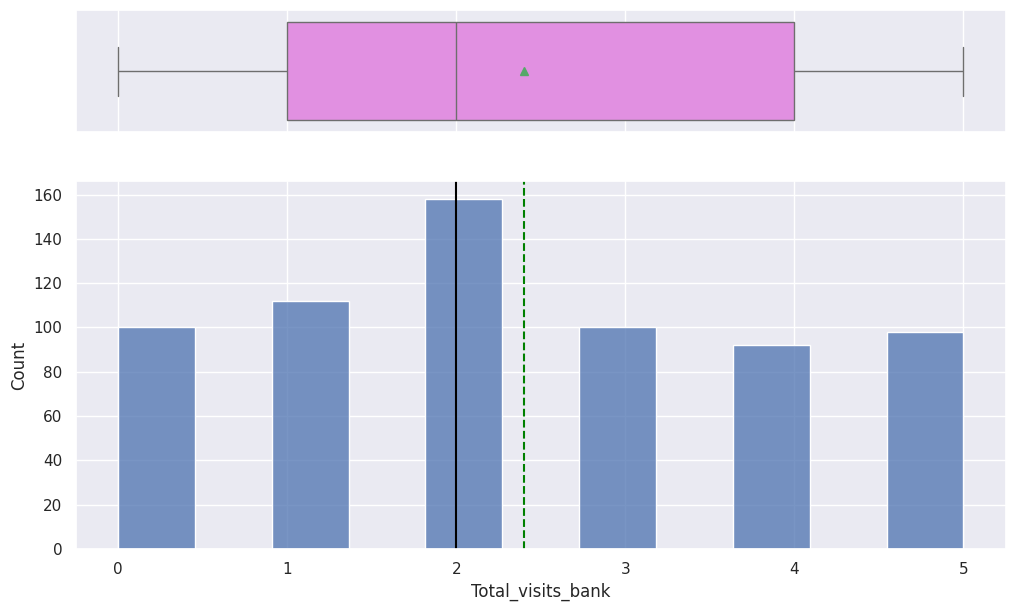

In [ ]:
histogram_boxplot(df, 'Total_visits_bank')


Observations: Most customers visited the bank in person an average of 2 times.

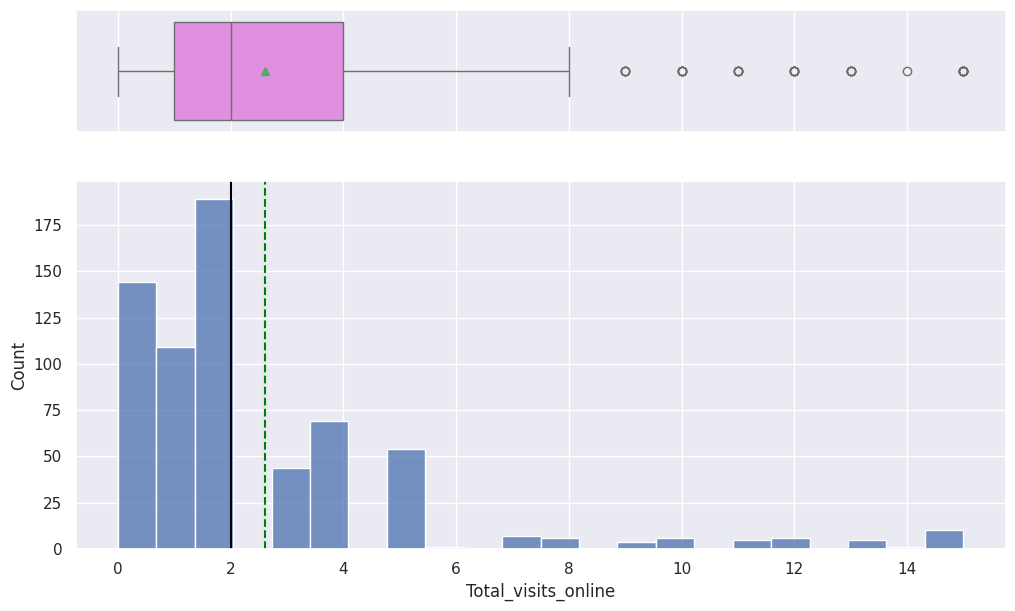

In [ ]:
histogram_boxplot(df, 'Total_visits_online')

Observations: The graph shows that most customers used online bank visits 0,1, or 2 times. There are many outliers in this column as well.

In [ ]:
# Calculate Q1
Q1= df.quantile(0.25)
# Calculate Q3
Q3= df.quantile(0.75)
IQR = Q3 - Q1

#Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile):\n{Q1}")
print(f"Q3 (75th percentile):\n{Q3}")
print(f"IQR (Interquartile Range):\n{IQR}")
print(f"Lower bound:\n{lower_bound}")
print(f"Upper bound:\n{upper_bound}")

# Identify outliers
outliers = df[(df['Total_visits_online'] < lower_bound['Total_visits_online']) | (df['Total_visits_online'] > upper_bound['Total_visits_online'])]
print(f'\nNumbers of outliers detected: {len(outliers)}')
print('Outliers:')
display(outliers)

Q1 (25th percentile):
Avg_Credit_Limit           10000.0
Total_Credit_Cards             3.0
Total_visits_bank              1.0
Total_visits_online            1.0
Total_calls_made               1.0
Avg_Credit_Limit_Capped    10000.0
Name: 0.25, dtype: float64
Q3 (75th percentile):
Avg_Credit_Limit           48000.0
Total_Credit_Cards             6.0
Total_visits_bank              4.0
Total_visits_online            4.0
Total_calls_made               5.0
Avg_Credit_Limit_Capped    48000.0
Name: 0.75, dtype: float64
IQR (Interquartile Range):
Avg_Credit_Limit           38000.0
Total_Credit_Cards             3.0
Total_visits_bank              3.0
Total_visits_online            3.0
Total_calls_made               4.0
Avg_Credit_Limit_Capped    38000.0
dtype: float64
Lower bound:
Avg_Credit_Limit          -47000.0
Total_Credit_Cards            -1.5
Total_visits_bank             -3.5
Total_visits_online           -3.5
Total_calls_made              -5.0
Avg_Credit_Limit_Capped   -47000.0
dtype: 

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Avg_Credit_Limit_Capped
1,50000,3,0,10,9,50000.0
4,100000,6,0,12,3,100000.0
6,100000,5,0,11,2,100000.0
612,157000,9,1,14,1,105000.0
613,94000,9,1,11,0,94000.0
615,131000,9,1,10,1,105000.0
616,96000,10,1,11,2,96000.0
617,136000,8,0,13,0,105000.0
618,121000,7,0,13,2,105000.0
619,158000,7,0,13,0,105000.0


In [ ]:
# Cap the outliers
df['Total_visits_online_Capped'] = np.where(df['Total_visits_online'] > upper_bound['Total_visits_online'], upper_bound['Total_visits_online'], np.where(df['Total_visits_online'] < lower_bound['Total_visits_online'], lower_bound['Total_visits_online'], df['Total_visits_online']))
display(df.tail(10))

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped
650,195000,10,1,12,2,105000.0,8.5
651,132000,9,1,12,2,105000.0,8.5
652,156000,8,1,8,0,105000.0,8.0
653,95000,10,0,15,1,95000.0,8.5
654,172000,10,1,9,1,105000.0,8.5
655,99000,10,1,10,0,99000.0,8.5
656,84000,10,1,13,2,84000.0,8.5
657,145000,8,1,9,1,105000.0,8.5
658,172000,10,1,15,0,105000.0,8.5
659,167000,9,0,12,2,105000.0,8.5


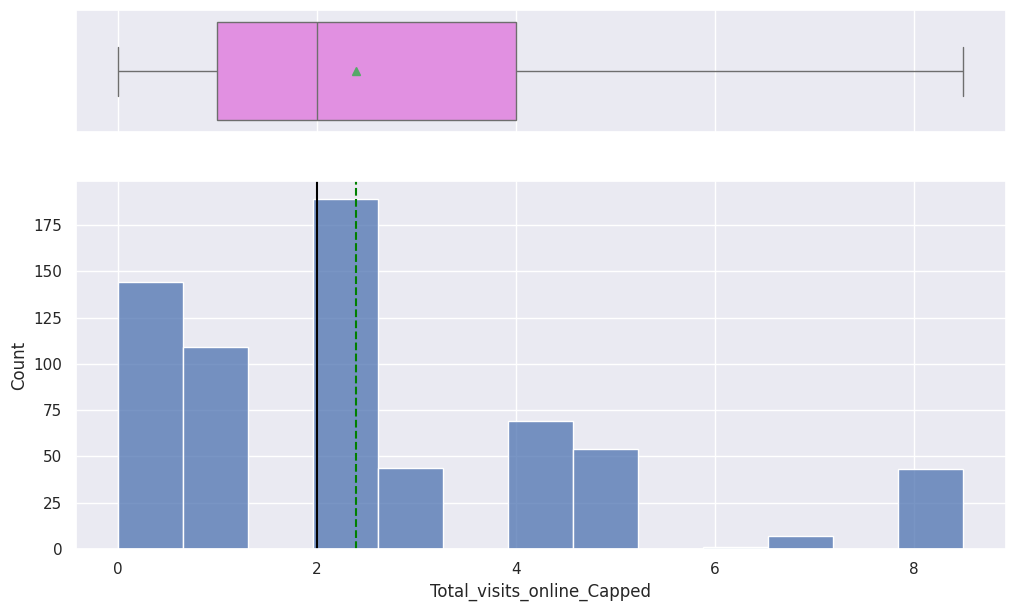

In [ ]:
histogram_boxplot(df, 'Total_visits_online_Capped')


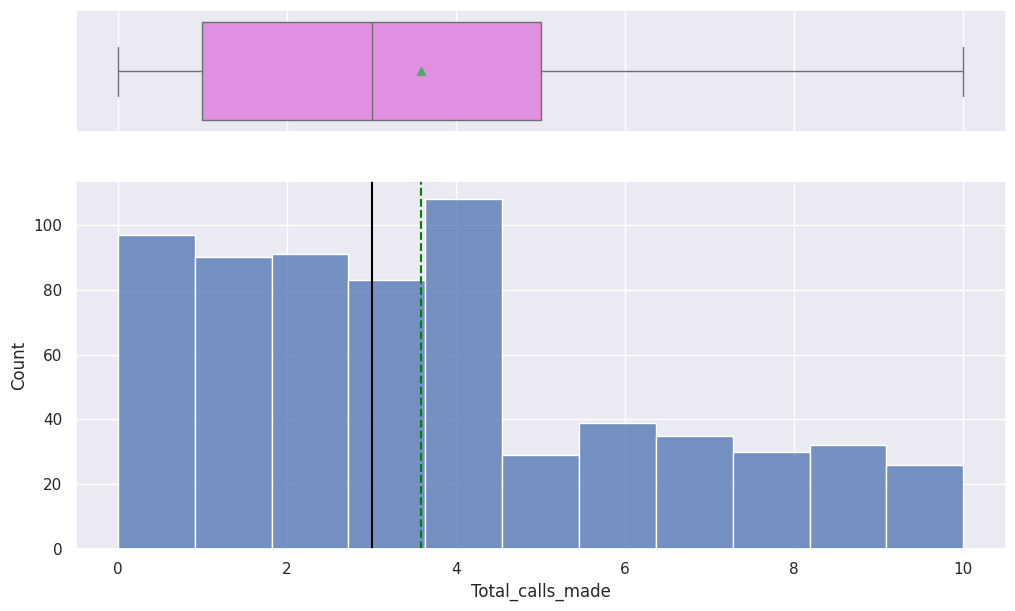

In [ ]:
histogram_boxplot(df, 'Total_calls_made')

The chart shows that most users made between 0 and 4 calls to the bank.

In [ ]:
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped
0,100000,2,1,1,0,100000.0,1.0
1,50000,3,0,10,9,50000.0,8.5
2,50000,7,1,3,4,50000.0,3.0
3,30000,5,1,1,4,30000.0,1.0
4,100000,6,0,12,3,100000.0,8.5


In [ ]:
df.drop(['Avg_Credit_Limit','Total_visits_online'], axis=1, inplace=True)

In [ ]:
df.head()


,Total_Credit_Cards,Total_visits_bank,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped
0,2,1,0,100000.0,1.0
1,3,0,9,50000.0,8.5
2,7,1,4,50000.0,3.0
3,5,1,4,30000.0,1.0
4,6,0,3,100000.0,8.5


# Bivariate Analysis


In [ ]:
# Correlation Check
df.corr()

,Total_Credit_Cards,Total_visits_bank,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped
Total_Credit_Cards,1.000000,0.315796,-0.651251,0.616470,0.042849
Total_visits_bank,0.315796,1.000000,-0.506016,-0.017170,-0.612388
Total_calls_made,-0.651251,-0.506016,1.000000,-0.452703,0.243771
Avg_Credit_Limit_Capped,0.616470,-0.017170,-0.452703,1.000000,0.335118
Total_visits_online_Capped,0.042849,-0.612388,0.243771,0.335118,1.000000


<Axes: >

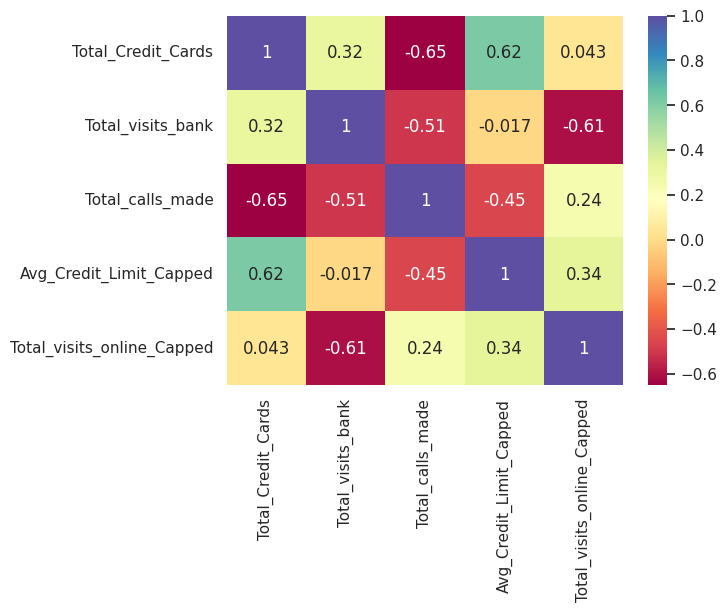

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='Spectral')

Observations:

*  Total_credit_cards: this variable has a slight positive correlation to Total_visits_bank, a moderate positive correlation to Total_visits_online, and a strong positive correlation to Avg_Credit_Limit.


*  Total_visits_bank: This variable has a slight positive correlation to Total_credit_cards.


*  Total_visits_online: only slight positive correlation to Total_credit cards, Total_calls_made, and Avg_Credit_Limit

*  Total_calls_made: only slight positive correlation to Total_visits_online.
*   Avg_Credit_Limit: Strong positive correlation to Total_credit_cards, which makes sense that someone with a higher credit limit might have more credit cards. There is also a slight positive correlation to Total_visits_online.












#### **Scaling the data**

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-1.24922476, -0.86045063, -1.25153737,  2.39894174, -0.6197673 ],
       [-0.78758515, -1.47373077,  1.89185881,  0.64361851,  2.70581334],
       [ 1.05897329, -0.86045063,  0.1455276 ,  0.64361851,  0.2670542 ],
       ...,
       [ 1.5206129 , -0.86045063, -0.90227113,  2.57447406,  2.70581334],
       [ 2.44389211, -0.86045063, -1.25153737,  2.57447406,  2.70581334],
       [ 1.9822525 , -1.47373077, -0.55300488,  2.57447406,  2.70581334]])

In [ ]:
pd.DataFrame(df_scaled)

,0,1,2,3,4
0,-1.249225,-0.860451,-1.251537,2.398942,-0.619767
1,-0.787585,-1.473731,1.891859,0.643619,2.705813
2,1.058973,-0.860451,0.145528,0.643619,0.267054
3,0.135694,-0.860451,0.145528,-0.058511,-0.619767
4,0.597334,-1.473731,-0.203739,2.398942,2.705813
...,...,...,...,...,...
655,2.443892,-0.860451,-1.251537,2.363835,2.705813
656,2.443892,-0.860451,-0.553005,1.837238,2.705813
657,1.520613,-0.860451,-0.902271,2.574474,2.705813
658,2.443892,-0.860451,-1.251537,2.574474,2.705813


#### **Applying PCA on scaled data**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# Defining the number of Principal components to generate
n = df_scaled.shape[1]
pca = PCA(n_components=df_scaled.shape[1], random_state = 0)
pca.fit(df_scaled)
pca_df = (pca.transform(df_scaled))

# Get Explained Variance
exp_var = pca.explained_variance_ratio_
exp_var

array([0.47196473, 0.34519351, 0.06514194, 0.06213265, 0.05556717])

In [ ]:
pca_df = pd.DataFrame(pca_df)
pca_df.head()


,0,1,2,3,4
0,-0.734723,0.899287,-2.703778,0.838429,-0.802747
1,2.380586,2.694705,0.696136,0.669049,-0.496104
2,-0.339927,1.185279,-0.038852,-0.085190,0.916153
3,0.282966,0.009492,-0.616228,-0.216924,0.812741
4,-0.285443,3.885192,-0.154630,0.305353,-0.594306


In [ ]:
pca_df.shape

(660, 5)

In [ ]:
pca_df.var()


,0
0,2.363405
1,1.728587
2,0.326204
3,0.311135
4,0.278257


In [ ]:
pca_df.var().sum()

5.007587253414263

In [ ]:
pca.explained_variance_ratio_


array([0.47196473, 0.34519351, 0.06514194, 0.06213265, 0.05556717])

In [ ]:
sum(pca.explained_variance_ratio_[:4])

0.9444328339761104

Looking at the explained variance ratio, it appears that 4 components can explain about 94% of the total variance of the data. The next steps will confirm if that is the best number to use.

## **K-Means**

Let us now fit the K-means algorithm on our pca components and find out the optimum number of clusters to use.

We will do this in 3 steps:
1. Initialize a dictionary to store the Sum of Squared Error (SSE) for each K
2. Run for a range of Ks and store SSE for each run
3. Plot the SSE vs K and plot the elbow curve

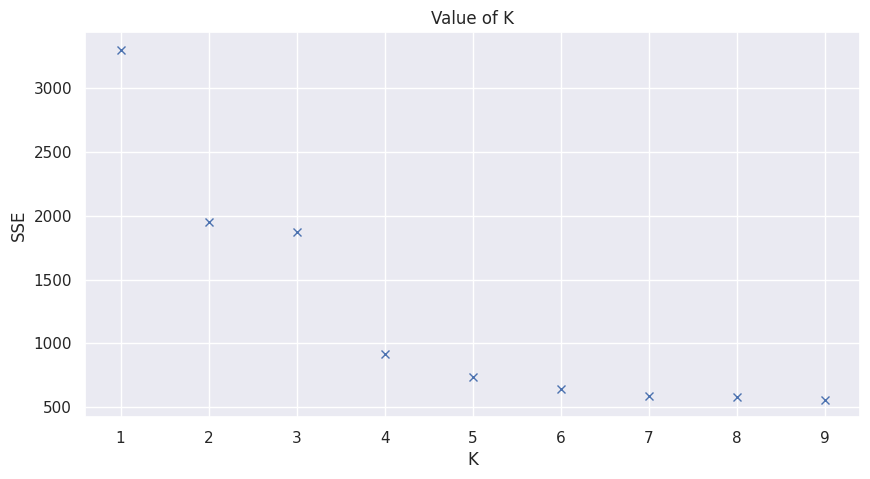

In [ ]:
# Elbow method to find optimum number of clusters
sse= {}
for k in range (1, 10):
    kmeans = KMeans(n_clusters = k, max_iter = 1000, random_state = 1).fit(pca_df)
    sse[k] = kmeans.inertia_

plt.figure(figsize=(10, 5))
plt.plot(list(sse.keys()), list(sse.values()), 'bx')
plt.title('Value of K')
plt.xlabel('K')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

Number of Clusters: 1 	Average Distortion: 3300.0000000000027
Number of Clusters: 2 	Average Distortion: 1949.9046848867488
Number of Clusters: 3 	Average Distortion: 1869.5749127805234
Number of Clusters: 4 	Average Distortion: 919.7516398734649
Number of Clusters: 5 	Average Distortion: 735.4138531711575
Number of Clusters: 6 	Average Distortion: 640.4797947943721
Number of Clusters: 7 	Average Distortion: 588.8316065890751
Number of Clusters: 8 	Average Distortion: 582.9907271595513
Number of Clusters: 9 	Average Distortion: 558.3345457926553


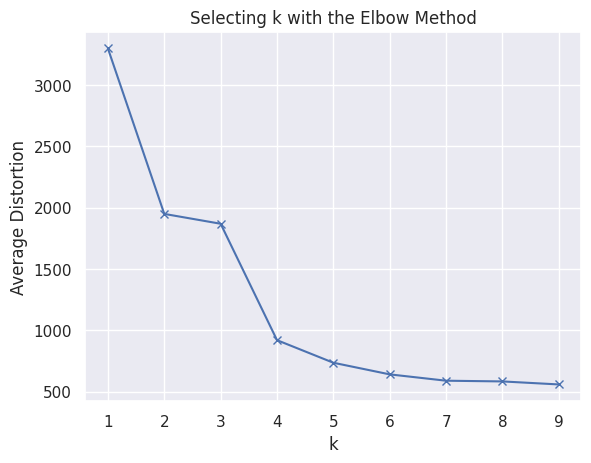

In [ ]:
clusters = range(1,10)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters = k, random_state= 1, n_init="auto")
    model.fit(pca_df)
    prediction = model.predict(pca_df)
    distortion = model.inertia_
    meanDistortions.append(distortion)

    print(  'Number of Clusters:', k, '\tAverage Distortion:', distortion)

plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average Distortion')
plt.title('Selecting k with the Elbow Method')
plt.show()

Based on the chart, a K value of 3 or 4 might work, but we will work with 4 since the explained variance of 4 components encompasses roughly 94% of the data; whereas 3 components only encompases roughly about 88%.

- Interpret the above elbow plot and state the reason for choosing the particular value of K
- Fit the K-means algorithms on the pca components with the number of clusters for the chosen value of K

In [ ]:
from sklearn.cluster import KMeans

# Re-initialize df to ensure it has all preprocessing steps applied consistently
df_processed = pd.read_excel("/content/drive/MyDrive/Credit Card Customer Data.xlsx")
df_processed = df_processed.drop(['Sl_No', 'Customer Key'], axis=1)

# Recalculate Q1, Q3, IQR, and bounds on the fresh df_processed
Q1 = df_processed.quantile(0.25)
Q3 = df_processed.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping for 'Avg_Credit_Limit'
df_processed['Avg_Credit_Limit_Capped'] = np.where(
    df_processed['Avg_Credit_Limit'] > upper_bound['Avg_Credit_Limit'],
    upper_bound['Avg_Credit_Limit'],
    np.where(df_processed['Avg_Credit_Limit'] < lower_bound['Avg_Credit_Limit'],
             lower_bound['Avg_Credit_Limit'],
             df_processed['Avg_Credit_Limit'])
)

# Apply capping for 'Total_visits_online'
df_processed['Total_visits_online_Capped'] = np.where(
    df_processed['Total_visits_online'] > upper_bound['Total_visits_online'],
    upper_bound['Total_visits_online'],
    np.where(df_processed['Total_visits_online'] < lower_bound['Total_visits_online'],
             lower_bound['Total_visits_online'],
             df_processed['Total_visits_online'])
)

# Drop the original columns after capping them
df_processed.drop(['Avg_Credit_Limit', 'Total_visits_online'], axis=1, inplace=True)

# Now, apply K-Means and add cluster labels to this correctly processed DataFrame
model = KMeans(n_clusters=4, random_state=1, n_init="auto") # Add n_init for newer sklearn versions
model.fit(pca_df)

cluster_labels = model.predict(pca_df)
df = df_processed # Assign the processed df back to the global df variable
df['Cluster_label'] = cluster_labels
df.head()

,Total_Credit_Cards,Total_visits_bank,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped,Cluster_label
0,2,1,0,100000.0,1.0,0
1,3,0,9,50000.0,8.5,1
2,7,1,4,50000.0,3.0,0
3,5,1,4,30000.0,1.0,0
4,6,0,3,100000.0,8.5,3


In [ ]:
model.predict(pca_df)

array([0, 1, 0, 0, 3, 1, 3, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2,
       2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2,
       2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 1, 2,
       2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2,
       1, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2,
       2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 2,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
model.predict(pca_df).shape

(660,)

<Axes: xlabel='0', ylabel='1'>

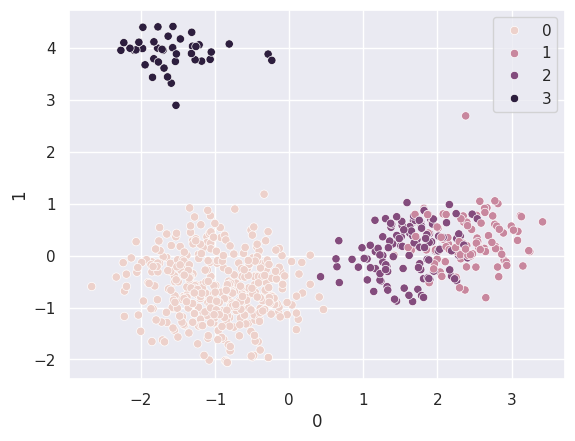

In [ ]:
sns.scatterplot(x=pca_df[0], y=pca_df[1], hue=model.predict(pca_df))

#### **Create the cluster profiles using the summary statistics and box plots for each label**

In [ ]:
cluster_profiles = df.groupby('Cluster_label')['Avg_Credit_Limit_Capped'].mean()
display(cluster_profiles)

,Avg_Credit_Limit_Capped
Cluster_label,
0,33851.948052
1,12464.646465
2,11904.761905
3,102660.000000


In [ ]:
cluster_profiles = df.groupby('Cluster_label')['Total_Credit_Cards'].mean()
display(cluster_profiles)

,Total_Credit_Cards
Cluster_label,
0,5.516883
1,2.292929
2,2.523810
3,8.740000


In [ ]:
cluster_profiles = df.groupby('Cluster_label')['Total_visits_online_Capped'].mean()
display(cluster_profiles)

,Total_visits_online_Capped
Cluster_label,
0,0.979221
1,3.813131
2,3.325397
3,8.180000


In [ ]:
cluster_profiles = df.groupby('Cluster_label')['Total_visits_bank'].mean()
display(cluster_profiles)

,Total_visits_bank
Cluster_label,
0,3.493506
1,0.888889
2,0.976190
3,0.600000


In [ ]:
cluster_profiles = df.groupby('Cluster_label')['Total_calls_made'].mean()
display(cluster_profiles)

,Total_calls_made
Cluster_label,
0,1.994805
1,8.737374
2,5.380952
3,1.080000


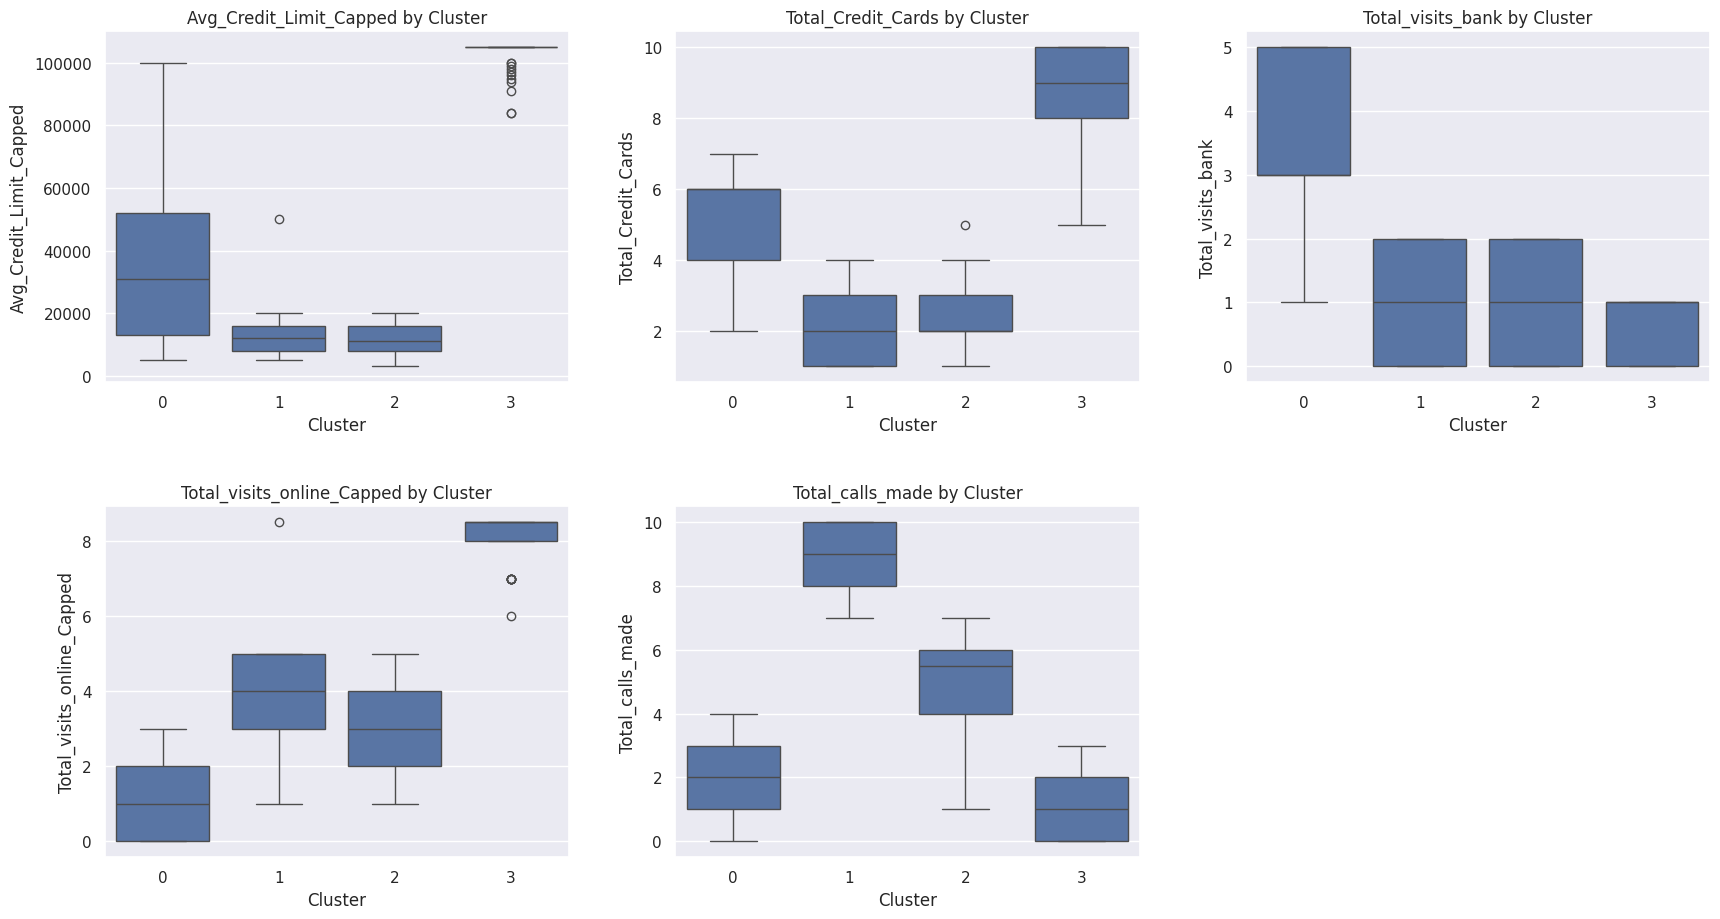

In [ ]:
numeric_columns = ['Avg_Credit_Limit_Capped', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online_Capped', 'Total_calls_made']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(ax = axes[i], x='Cluster_label', y=column, data=df)
    axes[i].set_title(f'{column} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(column)

for j in range(len(numeric_columns), len(axes)):
    axes[j].axis('off')

plt.tight_layout(pad=3.0)
plt.show()

### Cluster Profiles:


*  Cluster 0:


    *   Avg_Credit_Limit: This cluster contains the highest number of customers, with an average credit limit between $15K-$50K.

    *   Total_Credit_Cards: The average customer in this cluster has 4-6 credit cards.

    *  Total_visits_bank: Customers in this cluster average 3-5 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 0-2 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster averaged 1-3 calls to the bank.

*  Cluster 1:

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit between $5K and $15K.

    *   Total_Credit_Cards: The average customer in this cluster has 1-3 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-2 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 3-5 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 8-10 calls to the bank.

*  Cluster 2:

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit of $5K-$15K.

    *   Total_Credit_Cards: The average customer in this cluster has 2-3 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-2 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 2-4 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 4-6 calls to the bank.
*  Cluster 3:

    *   Avg_Credit_Limit: Customers in this cluster are a small group of customers with credit limits that are $80K+.

    *   Total_Credit_Cards: The average customer in this cluster has 8+ credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-1 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 6-9 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 0-2 calls to the bank.





## **Gaussian Mixture Model**

Let's now create clusters using the Gaussian Mixture Model.

- Apply the Gaussian Mixture Model algorithm on the pca components

In [ ]:
# Instantiate Gaussian Mixture Modeling
gmm = GaussianMixture(n_components=4, covariance_type = 'full', max_iter = 100, random_state=1)
gmm.fit(pca_df)



GaussianMixture(n_components=4, random_state=1)

#### **Create the cluster profiles using the summary statistics and box plots for each label**


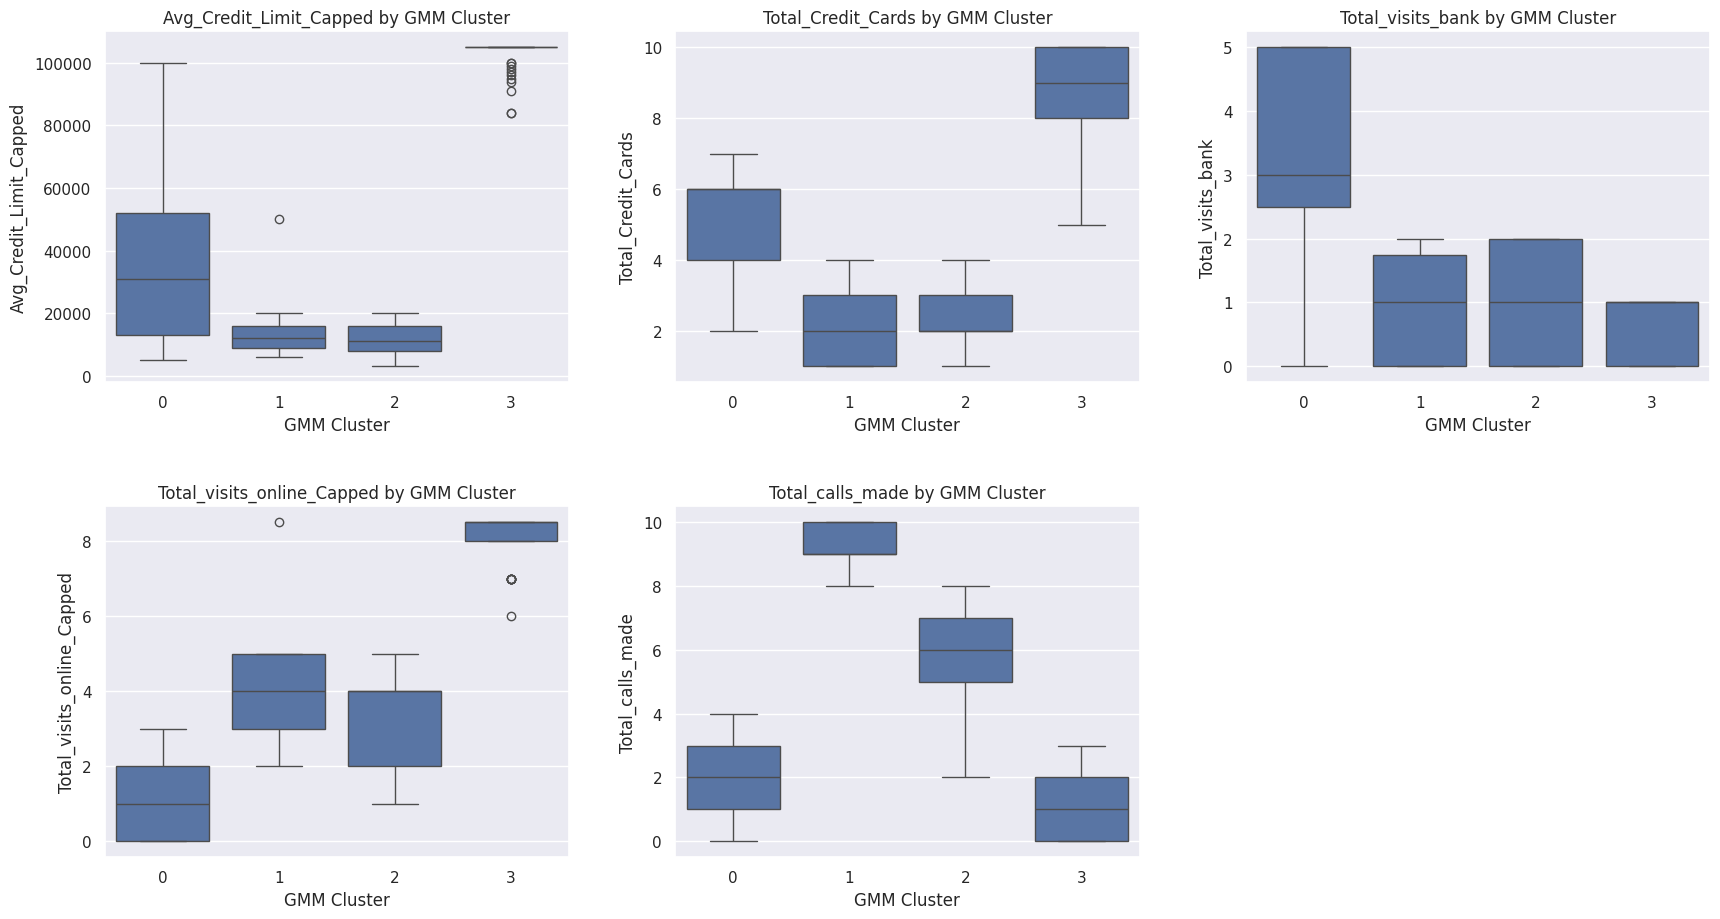

In [ ]:
# Define the numeric columns for plotting
numeric_columns = ['Avg_Credit_Limit_Capped', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online_Capped', 'Total_calls_made']

# Get GMM cluster labels
gmm_cluster_labels = gmm.predict(pca_df)

# Create a DataFrame with GMM cluster labels
df_gmm_clustered = df.copy() # Make a copy of the main DataFrame
df_gmm_clustered['GMM_Cluster'] = gmm_cluster_labels

# Create subplots for each numeric feature
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

for i, column in enumerate(numeric_columns):
    sns.boxplot(ax=axes[i], x='GMM_Cluster', y=column, data=df_gmm_clustered)
    axes[i].set_title(f'{column} by GMM Cluster')
    axes[i].set_xlabel('GMM Cluster')
    axes[i].set_ylabel(column)

# Turn off any unused subplots if fewer than 6 numeric columns
for j in range(len(numeric_columns), len(axes)):
    axes[j].axis('off')

plt.tight_layout(pad=3.0)
plt.show()

### Cluster Profiles:


*  Cluster 0:


    *   Avg_Credit_Limit: This cluster contains the highest number of customers, with an average credit limit between $15K-$50K.

    *   Total_Credit_Cards: The average customer in this cluster has 4-6 credit cards.

    *  Total_visits_bank: Customers in this cluster average 3-5 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 0-2 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster averaged 1-3 calls to the bank.

*  Cluster 1:

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit between $5K and $15K.

    *   Total_Credit_Cards: The average customer in this cluster has 1-3 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-2 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 3-5 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 8-10 calls to the bank.

*  Cluster 2:

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit of $5K-$15K.

    *   Total_Credit_Cards: The average customer in this cluster has 2-3 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-2 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 2-4 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 4-6 calls to the bank.
*  Cluster 3:

    *   Avg_Credit_Limit: Customers in this cluster are a small group of customers with credit limits that are $80K+.

    *   Total_Credit_Cards: The average customer in this cluster has 8+ credit cards.

    *  Total_visits_bank: Customers in this cluster average 0-1 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 6-9 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 0-2 calls to the bank.





#### **Compare the clusters from both algorithms - K-means and Gaussian Mixture Model**

### Comparing Clusters:
Both K-means and GMM clustering have identified 4 clusters of customer segmentation from the data. There are some notable similarities and differences:


*   Both algorithms identified a small, high value segment characterized by high credit limits, many credit cards, high online engagement, with very low in person visits or calls to the bank.  
*  Both algorithms identified a large segment of customers with moderate credit, a moderate amount of credit cards, who typically interact most frequently via in person visits and have a low engagement with both calls and online interactions.


*   Both models identified a segment of customers with low credit limits, few cards, and high engagement with calls to the bank. The GMM cluster also shows a moderate number of visits, making it slightly different than the KMeans Cluster 1 where the in person interaction is close to zero.







## **K-Medoids**



- Apply the K-Medoids clustering algorithm on the pca components

Count of observations in each K-Medoids cluster:
Kmedoids_Cluster
3    259
0    222
1    129
2     50
Name: count, dtype: int64


,Total_Credit_Cards,Total_visits_bank,Total_calls_made,Avg_Credit_Limit_Capped,Total_visits_online_Capped,Cluster_label
Kmedoids_Cluster,,,,,,
0,2.400901,0.932432,6.909910,12184.684685,3.565315,1.554054
1,5.224806,4.736434,2.015504,25581.395349,1.085271,0.000000
2,8.740000,0.600000,1.080000,102660.000000,8.180000,3.000000
3,5.644788,2.849421,1.996139,37691.119691,0.934363,0.023166


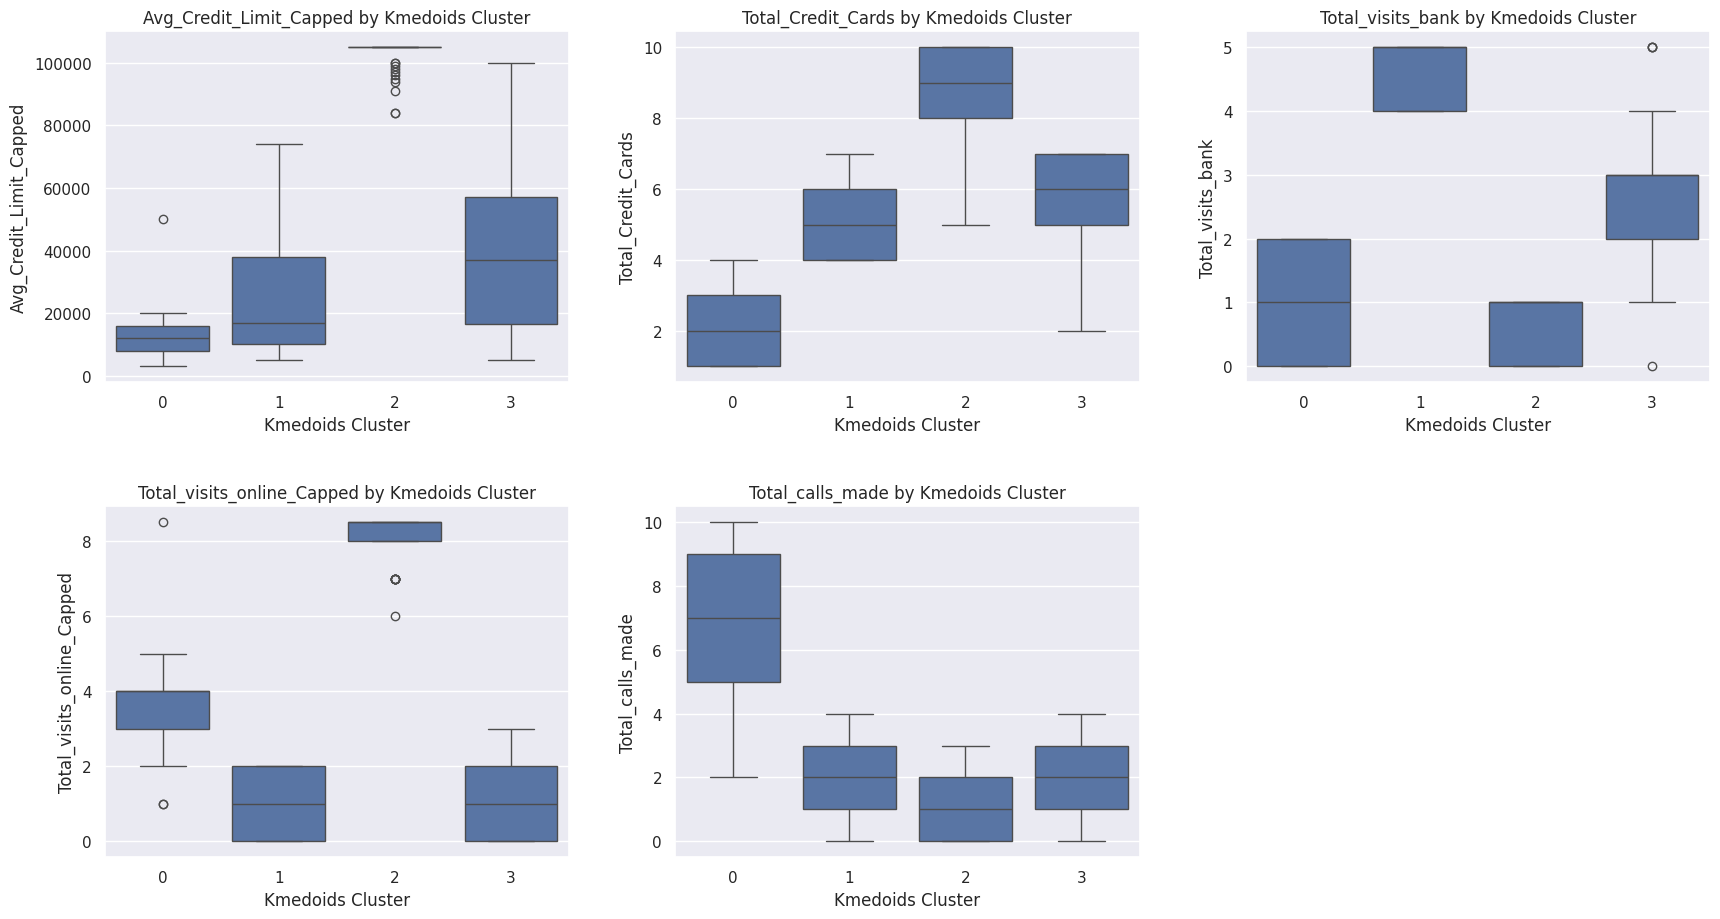

In [ ]:
kmedoids = KMedoids(n_clusters=4, random_state=1, init= 'k-medoids++')
kmedoids.fit(pca_df)
kmedoids_cluster_labels = kmedoids.predict(pca_df)

df_kmedoids_clustered = df.copy() # Make a copy of the main DataFrame
df_kmedoids_clustered['Kmedoids_Cluster']= kmedoids_cluster_labels

print("Count of observations in each K-Medoids cluster:")
print(df_kmedoids_clustered['Kmedoids_Cluster'].value_counts())

cluster_profile_kmedoids = df_kmedoids_clustered.groupby('Kmedoids_Cluster').mean()
display(cluster_profile_kmedoids)

numeric_columns_kmedoids = ['Avg_Credit_Limit_Capped', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online_Capped', 'Total_calls_made']

fig_kmedoids, axes_kmedoids = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes_kmedoids = axes_kmedoids.flatten()

for i, column in enumerate(numeric_columns_kmedoids):
    sns.boxplot(ax=axes_kmedoids[i], x='Kmedoids_Cluster', y=column, data=df_kmedoids_clustered)
    axes_kmedoids[i].set_title(f'{column} by Kmedoids Cluster')
    axes_kmedoids[i].set_xlabel('Kmedoids Cluster')
    axes_kmedoids[i].set_ylabel(column)

for j in range(len(numeric_columns_kmedoids), len(axes_kmedoids)):
  axes_kmedoids[j].axis('off')


plt.tight_layout(pad=3.0)
plt.show()

#### **Create cluster profiles using the summary statistics and box plots for each label**

### Cluster Profiles:


*  Cluster 0: 'Traditional & Moderately Engaged':

Customers in this cluster have low credit limits with a few cards, make frequent calls to the bank, and engage moderately online.


    *   Avg_Credit_Limit: This cluster contains customers with an average credit limit around $12K.

    *   Total_Credit_Cards: The average customer in this cluster has 2-4 credit cards.

    *  Total_visits_bank: Customers in this cluster average 1.5 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 3.8 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster averaged 8.7 calls to the bank.

*  Cluster 1: 'High Call, Low Credit':

This large segement of customers prefers in person banking, has moderate credit, and low online and call engagement.

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit around $37.5K.

    *   Total_Credit_Cards: The average customer in this cluster has 5.2 credit cards.

    *  Total_visits_bank: Customers in this cluster average 4.3 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 1 visit to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 2.2 calls to the bank.

*  Cluster 2: 'Elite Preferred':

This small segment of customers is characterized by high credit limits, many cards, and strong online preference with minimal direct interaction with the bank.

    *   Avg_Credit_Limit: Customers in this cluster have an average credit limit around $105K

    *   Total_Credit_Cards: The average customer in this cluster has 8.7 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0.9 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 8.5 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 1.1 calls to the bank.
*  Cluster 3:'Traditional & Low Engagement':

This segment of customers has lower credit but a moderate number of cards. The almost never visit the bank in person, and have both a low call and online engagement.

    *   Avg_Credit_Limit: Customers in this cluster have average credit limits around $21.6K.

    *   Total_Credit_Cards: The average customer in this cluster has 5.6 credit cards.

    *  Total_visits_bank: Customers in this cluster average 0 in person visits to the bank.


    *   Total_visits_online: Customers in this cluster average 1.1 visits to the online banking portal.

    *   Total_calls_made: Customers in this cluster average 2.8 calls to the bank.

#### **Compare the clusters from K-Means and K-Medoids**



*   **The 'Elite Preferred' segment:** This group of customers was the most consistently identified cluster across all 3 models (KMeans Cluster 3, GMM Cluster 1, and K-Medoids Cluster 2) and it represents the banks most valuable customers with very high credit limts, many credit cards, high online engagement, and very low in-person and call interaction.This robust identification suggests it is a distinct segment of the customer base.  
*  **The 'Traditional & Moderately Engaged' segment:** a large segment of customers with moderate credit and card usage, who primarily interact via in-person visits and typically have low engagement with calls and onine. This segment is also consistently identified across the models (KMeans Cluster 0, GMM Cluster 2, K-medoids Cluster 1). This group represents a significant portiton of the customer base.


*   **The "High Call, Low Credit" segment:** All models identify a segment with low credit limtis, few cards, and a high frequency of calls (KMeans Cluster 1, GMM Cluster 0, K-Mediods Cluster 0). There are some differences between the models with regard to bank visits and online engagement patterns. K-Medoids Cluster 0 shows moderate online interaction, while KMeans Cluster 1 shows very low bank visits.  
*  **The Traditional & Low engagement segment:** The remaining segments show the most variation between the models. These clusters represent customers with generally lower credit and varying degrees of online and call interaction, but are clearly less defined in terms of their primary interaction channel or value to the bank.





## **Conclusions and Business Recommendations**

All 3 clustering algorithms (KMeans, GMM, and K-Medoids) were able to identify robust customer segments. AllLife Bank can use this information to generate more targeted marketing strategies to appeal to the various types of customers.

### Recommendations per customer segment:  


*   **The 'Elite Preferred' segment:** Very high credit limits, high online engagement, few calls or visits. These are the banks most valuable customers.


    *  Possible marketing strategies: Exclusive invitations to premium digital services, early accesss to new digital banking features, personalized wealth management content, rewards for digital only transactions


    * Potential additional support services: Offer streamlined,  personalized, and secure digital wealth and portfolio management platforms with dedicated primary support channels (like premium email support for urgent queries).



*   **The 'Traditional & Moderately Engaged' Segment**: Moderate credit limits and card use, primary interaction via in-person visits, low online and call engagement.



    *   Possible marketing strategies: In-branch promotions, localized  advertising, direct mailing for traditional products (mortgages, personal loans, car loans), highlight the benefits of personalized service from "local people who know your name".  

    * Potential additional support services: Invest in enhancing the in person experience (comfortable furniture, efficient queue management and drive thru times, knowledgable staff). Train staff to assist in developing customer understanding of basic digital banking services.

*   **The 'High Call, Low Credit" segment** and **the 'Traditional & Low Engagement' segment** are pretty similar: Low credit limits, few cards, high frequency calls and variation in online use.

    *   Possible Marketing Strategies: Advertise products that build credit, offer financial literacy workshops, incentivize savings and checking accounts as part of the workshop, Emphasize self-service options through clear, simple messaging.


    * Potential additional support services: improve call center efficiency, reduce wait times, and empower employees to resolve issues quickly. Develop clear and concise FAQ literature and help sections on digital platforms, consider a dedicated staff support team to help guide customers through correct use of self service or to the correct department.






